## Agent的结构化输出 vs 模型的结构化输出
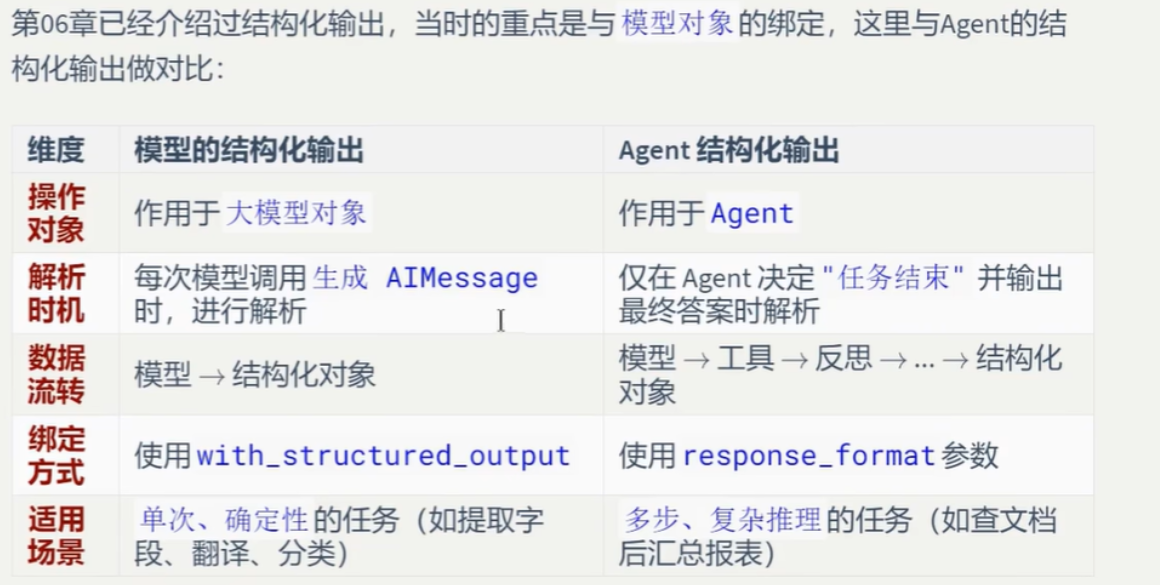



## 结构化输出的4种策略
### 1.ProviderStrategy

In [3]:
from pydantic import BaseModel, Field
from langchain.agents.structured_output import ProviderStrategy, ToolStrategy
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    # model="mistral-nemo:latest",
    model="qwen3-vl:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)
# 2.使用Pydantic结构方式来定义一个类
class ContactInfo(BaseModel):
    """用户的联系方式"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱")
    phone: str = Field(description="用户电话")


# 3.创建agent
agent = create_agent(
    model=model,
    tools=[],
    response_format=ProviderStrategy(ContactInfo), # 结构化输出的第一种方式
    system_prompt="Agent的行为指令" # 可选
)
# 3.调用
result = agent.invoke({
    "messages":[{"role":"user","content":"请提取项目文本的用户信息：王小明的email是 wxm1234@gmail.com,电话是13532677677"}]
})

rprint(result)

{
    'messages': [
        HumanMessage(
            content='请提取项目文本的用户信息：王小明的email是 wxm1234@gmail.com,电话是13532677677',
            additional_kwargs={},
            response_metadata={},
            id='f5c49dfa-5335-4ce2-958f-4cc4a720653b'
        ),
        AIMessage(
            content='{\n\n"name": "王小明",\n"email": "wxm1234@gmail.com",\n"phone": "13532677677"\n}',
            additional_kwargs={'parsed': None, 'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 1500,
                    'prompt_tokens': 54,
                    'total_tokens': 1554,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 19}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3-vl:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-959',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a0ff8c-c867-7453-a61f-5585058576c0-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 54,
                'output_tokens': 1500,
                'total_tokens': 1554,
                'input_token_details': {'cache_read': 19},
                'output_token_details': {}
            }
        )
    ],
    'structured_response': ContactInfo(name='王小明', email='wxm1234@gmail.com', phone='13532677677')
}

### 2.ToolStrategy

In [5]:
from pydantic import BaseModel, Field
from langchain.agents.structured_output import ToolStrategy
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    # model="mistral-nemo:latest",
    model="qwen3-vl:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)
# 2.使用Pydantic结构方式来定义一个类
class ContactInfo(BaseModel):
    """用户的联系方式"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱")
    phone: str = Field(description="用户电话")


# 3.创建agent
agent = create_agent(
    model=model,
    tools=[],
    response_format=ToolStrategy(ContactInfo), # 结构化输出的第一种方式
    system_prompt="Agent的行为指令" # 可选
)
# 3.调用
result = agent.invoke({
    "messages":[{"role":"user","content":"请提取项目文本的用户信息：王小明的email是 wxm1234@gmail.com,电话是13532677677"}]
})

rprint(result)

{
    'messages': [
        HumanMessage(
            content='请提取项目文本的用户信息：王小明的email是 wxm1234@gmail.com,电话是13532677677',
            additional_kwargs={},
            response_metadata={},
            id='012e4e03-59e1-424e-84fb-dbe89cac7ce5'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 409,
                    'prompt_tokens': 229,
                    'total_tokens': 638,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 6}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3-vl:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-304',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0ff93-cc54-7822-88dc-56fd95a240e5-0',
            tool_calls=[
                {
                    'name': 'ContactInfo',
                    'args': {'name': '王小明', 'email': 'wxm1234@gmail.com', 'phone': '13532677677'},
                    'id': 'call_46lcbl5u',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 229,
                'output_tokens': 409,
                'total_tokens': 638,
                'input_token_details': {'cache_read': 6},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content="Returning structured response: name='王小明' email='wxm1234@gmail.com' phone='13532677677'",
            name='ContactInfo',
            id='cb7d00d7-afe3-408b-b7e7-75860974d143',
            tool_call_id='call_46lcbl5u'
        )
    ],
    'structured_response': ContactInfo(name='王小明', email='wxm1234@gmail.com', phone='13532677677')
}

### 3.类型/AutoStrategy

In [7]:
from pydantic import BaseModel, Field
from langchain.agents.structured_output import AutoStrategy
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    # model="mistral-nemo:latest",
    model="qwen3-vl:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)
# 2.使用Pydantic结构方式来定义一个类
class ContactInfo(BaseModel):
    """用户的联系方式"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱")
    phone: str = Field(description="用户电话")


# 3.创建agent
agent = create_agent(
    model=model,
    tools=[],
    # response_format=AutoStrategy(ContactInfo), # 结构化输出的第3种方式
    response_format=ContactInfo, # 也可以怎么写，就是所谓的type，不过将来会不支持这种方式
    system_prompt="Agent的行为指令" # 可选
)
# 3.调用
result = agent.invoke({
    "messages":[{"role":"user","content":"请提取项目文本的用户信息：王小明的email是 wxm1234@gmail.com,电话是13532677677"}]
})

rprint(result)

{
    'messages': [
        HumanMessage(
            content='请提取项目文本的用户信息：王小明的email是 wxm1234@gmail.com,电话是13532677677',
            additional_kwargs={},
            response_metadata={},
            id='233c2261-ed8b-4e77-9aab-a79754d189ab'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 337,
                    'prompt_tokens': 229,
                    'total_tokens': 566,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 228}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3-vl:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-557',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0ff9e-04a7-7f71-b6a5-0b242c67e324-0',
            tool_calls=[
                {
                    'name': 'ContactInfo',
                    'args': {'name': '王小明', 'email': 'wxm1234@gmail.com', 'phone': '13532677677'},
                    'id': 'call_b1u5q8lj',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 229,
                'output_tokens': 337,
                'total_tokens': 566,
                'input_token_details': {'cache_read': 228},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content="Returning structured response: name='王小明' email='wxm1234@gmail.com' phone='13532677677'",
            name='ContactInfo',
            id='697e2f15-703b-4d8e-b814-6590e71ab601',
            tool_call_id='call_b1u5q8lj'
        )
    ],
    'structured_response': ContactInfo(name='王小明', email='wxm1234@gmail.com', phone='13532677677')
}